# 🐱 Cat Distress Detection — Feature Extraction & Modelling

**Goal:** Binary classification of cat meows into **distress** (isolation context) vs. **normal** (brushing + food contexts).



## 0 · Imports & Configuration

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

# ── Data & numerics ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Audio ─────────────────────────────────────────────────────────────────────
import librosa
import librosa.display
from scipy.signal import butter, sosfilt

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── ML ────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
import lightgbm as lgb
from tqdm import tqdm

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

print("All imports OK ✓")

All imports OK ✓


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

# Google Colab Setup
try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
    print("✓ Google Drive mounted")
except:
    print("✓ Running locally")

GDRIVE_BASE = '/content/drive/MyDrive/Electric Sheep/Beliz - EDA/Erin_PreprocessingandNotes/data/processed'
# Folder that contains BOTH the metadata CSV and all .wav files
DATA_DIR = GDRIVE_BASE  # Corrected to point to Google Drive base
METADATA_FILE = os.path.join(DATA_DIR, "metadata.csv")

# Audio parameters matching Erin's preprocessing output
NATIVE_SR       = 8_000   # Hz — files are already at 8 kHz, do NOT resample
TARGET_DURATION = 2.5     # seconds — files already padded/trimmed to this
N_SAMPLES       = int(NATIVE_SR * TARGET_DURATION)  # = 20,000 samples

# MFCC parameters
N_FFT  = 512
HOP_LENGTH = 128

# Classification threshold (fine tuned in Section 7)
DECISION_THRESHOLD = 0.3

print("Configuration loaded ✓")

Mounted at /content/drive
✓ Google Drive mounted
Configuration loaded ✓


---
## 1 · Load & Inspect Metadata

In [3]:
df = pd.read_csv(METADATA_FILE)
print(f"Shape: {df.shape}")
df.head()

Shape: (440, 18)


,filename,context,context_code,cat_id,breed,sex,neutered,owner_id,session,meow_num,distress_label,original_path,clipped,snr_db,pre_call_rms,onset_s,original_duration_s,flags
0,B_ANI01_MC_FN_SIM01_101.wav,brushing,B,ANI01,maine_coon,female,neutered,SIM01,1,1,0,cat_meows_data/B_ANI01_MC_FN_SIM01_101.wav,False,39.52,0.001081,0.52,2.281,NaN
1,B_ANI01_MC_FN_SIM01_102.wav,brushing,B,ANI01,maine_coon,female,neutered,SIM01,1,2,0,cat_meows_data/B_ANI01_MC_FN_SIM01_102.wav,False,22.33,0.000710,0.50,1.419,NaN
2,B_ANI01_MC_FN_SIM01_103.wav,brushing,B,ANI01,maine_coon,female,neutered,SIM01,1,3,0,cat_meows_data/B_ANI01_MC_FN_SIM01_103.wav,False,20.19,0.001535,0.40,1.799,NaN
3,B_ANI01_MC_FN_SIM01_301.wav,brushing,B,ANI01,maine_coon,female,neutered,SIM01,3,1,0,cat_meows_data/B_ANI01_MC_FN_SIM01_301.wav,False,23.67,0.003144,0.39,1.740,NaN
4,B_ANI01_MC_FN_SIM01_302.wav,brushing,B,ANI01,maine_coon,female,neutered,SIM01,3,2,0,cat_meows_data/B_ANI01_MC_FN_SIM01_302.wav,False,24.33,0.001098,0.44,1.268,NaN


In [4]:
print(METADATA_FILE)

/content/drive/MyDrive/Electric Sheep/Beliz - EDA/Erin_PreprocessingandNotes/data/processed/metadata.csv


In [5]:
# ── Basic overview ────────────────────────────────────────────────────────────
print("=== Column dtypes ===")
print(df.dtypes)
print("\n=== Missing values ===")
print(df.isnull().sum())
print("\n=== Context distribution ===")
print(df['context'].value_counts())
print("\n=== Distress label distribution ===")
print(df['distress_label'].value_counts())
print("\n=== Unique cats ===")
print(f"{df['cat_id'].nunique()} cats, IDs: {sorted(df['cat_id'].unique())}")

=== Column dtypes ===
filename                object
context                 object
context_code            object
cat_id                  object
breed                   object
sex                     object
neutered                object
owner_id                object
session                  int64
meow_num                 int64
distress_label           int64
original_path           object
clipped                   bool
snr_db                 float64
pre_call_rms           float64
onset_s                float64
original_duration_s    float64
flags                   object
dtype: object

=== Missing values ===
filename                 0
context                  0
context_code             0
cat_id                   0
breed                    0
sex                      0
neutered                 0
owner_id                 0
session                  0
meow_num                 0
distress_label           0
original_path            0
clipped                  0
snr_db                   0
pre_

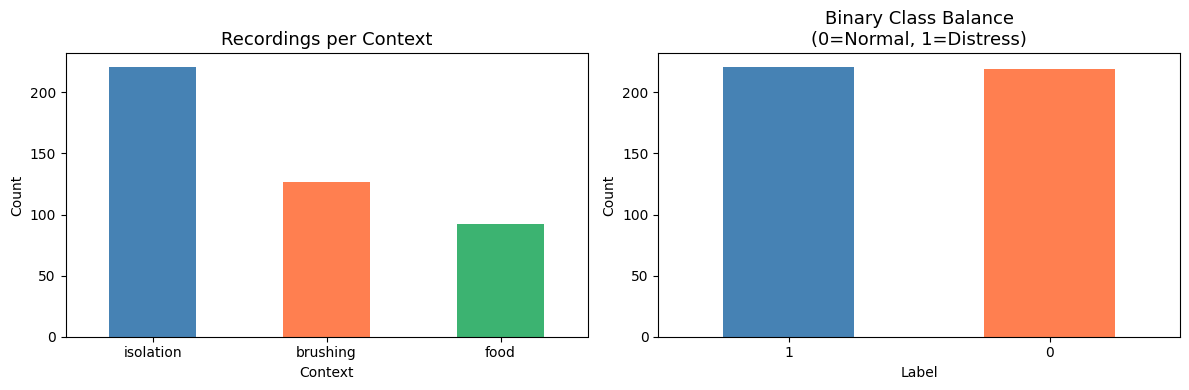

Class balance — Distress: 50.2% | Normal: 49.8%


In [6]:
# ── Distress label meaning ────────────────────────────────────────────────────
# 0 = brushing   (normal)
# 1 = isolation  (DISTRESS)
# 2 = food       (normal)
#
# Binary target: 1 (isolation) → distress=1, everything else → distress=0

df['binary_label'] = (df['distress_label'] == 1).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['context'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','coral','mediumseagreen'])
axes[0].set_title('Recordings per Context', fontsize=13)
axes[0].set_xlabel('Context')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['binary_label'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue','coral'])
axes[1].set_title('Binary Class Balance\n(0=Normal, 1=Distress)', fontsize=13)
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

distress_pct = df['binary_label'].mean() * 100
print(f"Class balance — Distress: {distress_pct:.1f}% | Normal: {100-distress_pct:.1f}%")

---
## 2 · Quality Filtering

The `flags` column contains quality annotations from your collaborator's preprocessing:
- `LOW_SNR` — poor signal-to-noise ratio
- `EARLY_ONSET` — meow starts too close to the beginning of the clip
- `DURATION_OUTLIER` — clip is unusually long

Strategy: **exclude `LOW_SNR`** (genuinely bad audio). Keep `EARLY_ONSET` and `DURATION_OUTLIER` since they still contain valid vocalisations and removing them would reduce the already modest dataset size.

In [7]:
# ── Parse flags ───────────────────────────────────────────────────────────────
df['flags'] = df['flags'].fillna('')
df['has_low_snr'] = df['flags'].str.contains('LOW_SNR')
df['has_early_onset'] = df['flags'].str.contains('EARLY_ONSET')
df['has_duration_outlier'] = df['flags'].str.contains('DURATION_OUTLIER')

print("Flag counts:")
print(f"  LOW_SNR:          {df['has_low_snr'].sum()}")
print(f"  EARLY_ONSET:      {df['has_early_onset'].sum()}")
print(f"  DURATION_OUTLIER: {df['has_duration_outlier'].sum()}")

# Filter out LOW_SNR only
df_clean = df[~df['has_low_snr']].copy().reset_index(drop=True)
print(f"\nAfter removing LOW_SNR: {len(df)} → {len(df_clean)} recordings")

Flag counts:
  LOW_SNR:          6
  EARLY_ONSET:      90
  DURATION_OUTLIER: 5

After removing LOW_SNR: 440 → 434 recordings


In [8]:
# ── Verify audio files exist ───────────────────────────────────────────────────
# The filename column contains just the basename; files live in DATA_DIR
df_clean['filepath'] = df_clean['filename'].apply(lambda f: os.path.join(DATA_DIR, f))

missing = df_clean[~df_clean['filepath'].apply(os.path.exists)]
if len(missing) > 0:
    print(f"⚠ WARNING: {len(missing)} audio files not found. Example: {missing['filepath'].iloc[0]}")
    print("  → Dropping missing files before feature extraction.")
    df_clean = df_clean[df_clean['filepath'].apply(os.path.exists)].reset_index(drop=True)
else:
    print(f"All {len(df_clean)} audio files found ✓")

All 434 audio files found ✓


## 3 · Load Preprocessed Data

In [9]:
def load_audio(filepath: str) -> np.ndarray:
    """
    Load a preprocessed .wav file exactly as-is.

    Erin's pipeline outputs: 8 kHz mono, 2.5 s (20,000 samples), 16-bit WAV.
    - No resampling: 8 kHz is the native hardware rate; upsampling adds nothing.
    - No low-pass filter: Nyquist IS 4 kHz at 8 kHz sample rate.
    - No amplitude normalisation: consistent collar placement means
      raw amplitude carries real signal (louder = more arousal).
    """
    y, sr = librosa.load(filepath, sr=None, mono=True)  # sr=None preserves native rate

    assert sr == NATIVE_SR, f"Unexpected sample rate {sr} in {filepath}"

    # Safety: enforce exact length in case of any rounding
    if len(y) < N_SAMPLES:
        y = np.pad(y, (0, N_SAMPLES - len(y)))
    else:
        y = y[:N_SAMPLES]

    return y

# Sanity check
sample = load_audio(df_clean['filepath'].iloc[0])
print(f"Shape  : {sample.shape}  (expected {N_SAMPLES})")
print(f"SR used: {NATIVE_SR} Hz")
print(f"Range  : [{sample.min():.4f}, {sample.max():.4f}]")

Shape  : (20000,)  (expected 20000)
SR used: 8000 Hz
Range  : [-0.3134, 0.2830]


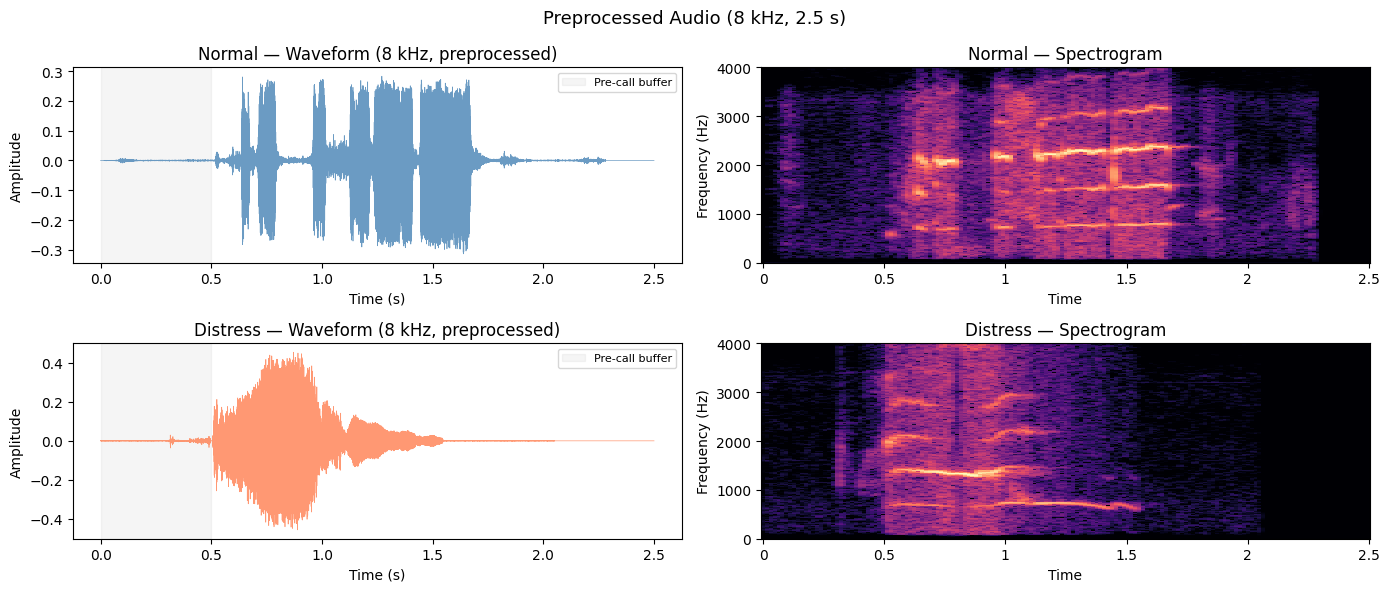

In [10]:
# Visualise one normal vs one distress clip (already preprocessed)
dist_path   = df_clean[df_clean['binary_label'] == 1]['filepath'].iloc[0]
normal_path = df_clean[df_clean['binary_label'] == 0]['filepath'].iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 6))
t = np.linspace(0, TARGET_DURATION, N_SAMPLES)

for i, (path, label) in enumerate([(normal_path, 'Normal'), (dist_path, 'Distress')]):
    y = load_audio(path)
    colour = 'steelblue' if i == 0 else 'coral'

    # Waveform
    axes[i, 0].plot(t, y, lw=0.5, color=colour, alpha=0.8)
    axes[i, 0].axvspan(0, 0.5, alpha=0.08, color='gray', label='Pre-call buffer')
    axes[i, 0].set_title(f'{label} — Waveform (8 kHz, preprocessed)')
    axes[i, 0].set_xlabel('Time (s)')
    axes[i, 0].set_ylabel('Amplitude')
    axes[i, 0].legend(fontsize=8)

    # Spectrogram
    D = librosa.amplitude_to_db(
        np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)), ref=np.max
    )
    librosa.display.specshow(D, sr=NATIVE_SR, hop_length=HOP_LENGTH,
                             x_axis='time', y_axis='hz', ax=axes[i, 1])
    axes[i, 1].set_ylim(0, 4000)
    axes[i, 1].set_title(f'{label} — Spectrogram')
    axes[i, 1].set_ylabel('Frequency (Hz)')

plt.suptitle('Preprocessed Audio (8 kHz, 2.5 s)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4 · Feature Extraction

We extract **four feature groups** per clip, all operating on the preprocessed audio:

| Group | Features | Why useful |
|---|---|---|
| **MFCCs** | mean + std of 20 coefficients (40 total) | Compact vocal timbre representation |
| **Spectral** | centroid, bandwidth, rolloff, contrast, flatness, ZCR | Characterise brightness, noisiness, distribution of energy |
| **Temporal** | RMS energy (mean/std), onset rate | Capture amplitude dynamics and rhythm |
| **Pitch** | fundamental frequency mean/std, voiced ratio | Distress meows tend to be higher-pitched and more variable |

Total: **113 features** per recording.

In [11]:
# MFCC parameters (following Ntalampiras et al. 2019)
N_MFCC      = 13
N_MELS      = 23
N_FFT       = 512         # ~64 ms at 8 kHz — appropriate for this sample rate
HOP_LENGTH  = 128

def extract_features(y: np.ndarray, sr: int = NATIVE_SR) -> dict:
    """
    Extract acoustic features from a preprocessed 8 kHz cat meow clip.

    Feature groups
    ──────────────
    MFCCs         : 13 coefficients × (mean, std) + delta × (mean, std) = 52
                    Matches Ntalampiras et al. (2019) filterbank/MFCC setup.
    Spectral      : centroid, bandwidth, rolloff, flatness, contrast, ZCR = 24
    Spectral ent. : Erin notes this is effective for stress; captures tonal vs noisy = 2
    Temporal      : RMS mean/std, onset rate, temporal centroid = 4
    Pitch (F0)    : mean, std, voiced ratio via pyin = 3
    ──────────────────────────────────────────────────────────────────────────
    Total: 85 features

    Notes
    -----
    - fmin/fmax for pyin: C2 (~65 Hz) to C6 (~1047 Hz) appropriate for cat vocalisations
      within the 0–4 kHz hardware ceiling.
    - The pre-call silence window (first 0.5 s) is NOT stripped here —
      the original authors handled silence at analysis time, not file level.
      Features are computed over the full 2.5 s clip, consistent with training.
    """
    features = {}

    # ── 1. MFCCs (13 coefficients → 52 features) ─────────────────────────────
    mfccs = librosa.feature.mfcc(
        y=y, sr=sr,
        n_mfcc=N_MFCC,
        n_mels=N_MELS,    # 23 filterbanks — matches the paper
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )
    for i in range(N_MFCC):
        features[f'mfcc_{i+1}_mean'] = float(np.mean(mfccs[i]))
        features[f'mfcc_{i+1}_std']  = float(np.std(mfccs[i]))

    delta_mfcc = librosa.feature.delta(mfccs)
    for i in range(N_MFCC):
        features[f'delta_mfcc_{i+1}_mean'] = float(np.mean(delta_mfcc[i]))
        features[f'delta_mfcc_{i+1}_std']  = float(np.std(delta_mfcc[i]))

    # ── 2. Spectral features (24 features) ───────────────────────────────────
    spec_centroid  = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
    spec_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
    spec_rolloff   = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
    spec_flatness  = librosa.feature.spectral_flatness(y=y, n_fft=N_FFT, hop_length=HOP_LENGTH)
    spec_contrast  = librosa.feature.spectral_contrast(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_bands=4)
    zcr            = librosa.feature.zero_crossing_rate(y, hop_length=HOP_LENGTH)

    for name, arr in [
        ('centroid',  spec_centroid),
        ('bandwidth', spec_bandwidth),
        ('rolloff',   spec_rolloff),
        ('flatness',  spec_flatness),
        ('zcr',       zcr),
    ]:
        features[f'spectral_{name}_mean'] = float(np.mean(arr))
        features[f'spectral_{name}_std']  = float(np.std(arr))

    # Spectral contrast per sub-band (7 bands × 2 stats = 14)
    for band_i in range(spec_contrast.shape[0]):   # shape[0] is n_bands + 1 = 5
      features[f'spec_contrast_b{band_i+1}_mean'] = float(np.mean(spec_contrast[band_i]))
      features[f'spec_contrast_b{band_i+1}_std']  = float(np.std(spec_contrast[band_i]))

    # ── 3. Spectral entropy (2 features) ─────────────────────────────────────
    # Captures tonal↔noise continuum; Erin flags this as relevant for stress.
    stft_mag = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH))
    # Normalise each frame to a probability distribution, then compute entropy
    stft_norm = stft_mag / (stft_mag.sum(axis=0, keepdims=True) + 1e-10)
    frame_entropy = -np.sum(stft_norm * np.log2(stft_norm + 1e-10), axis=0)
    features['spectral_entropy_mean'] = float(np.mean(frame_entropy))
    features['spectral_entropy_std']  = float(np.std(frame_entropy))

    # ── 4. Temporal / energy features (4 features) ───────────────────────────
    rms = librosa.feature.rms(y=y, hop_length=HOP_LENGTH)
    features['rms_mean'] = float(np.mean(rms))
    features['rms_std']  = float(np.std(rms))

    onsets = librosa.onset.onset_detect(y=y, sr=sr, hop_length=HOP_LENGTH)
    features['onset_rate'] = len(onsets) / TARGET_DURATION  # onsets per second

    frame_times = librosa.frames_to_time(np.arange(rms.shape[1]), sr=sr, hop_length=HOP_LENGTH)
    rms_flat    = rms.flatten()
    total_energy = rms_flat.sum()
    features['temporal_centroid'] = (
        float(np.dot(frame_times, rms_flat) / total_energy) if total_energy > 0 else 0.0
    )

    # ── 5. Pitch / F0 features (3 features) ──────────────────────────────────
    # fmax=1047 Hz (C6): well within 4 kHz ceiling and covers cat vocalisation range
    f0, voiced_flag, _ = librosa.pyin(
        y,
        fmin=librosa.note_to_hz('C2'),   # ~65 Hz
        fmax=librosa.note_to_hz('C6'),   # ~1047 Hz
        sr=sr
    )
    voiced_f0 = f0[voiced_flag == 1] if voiced_flag is not None else np.array([])
    features['f0_mean']      = float(np.mean(voiced_f0))  if len(voiced_f0) > 0 else 0.0
    features['f0_std']       = float(np.std(voiced_f0))   if len(voiced_f0) > 0 else 0.0
    features['voiced_ratio'] = float(np.sum(voiced_flag)) / len(voiced_flag) if voiced_flag is not None else 0.0

    return features

# Sanity check
test_feats = extract_features(sample)
print(f"Features extracted: {len(test_feats)}")

Features extracted: 81


In [12]:
# Extract features for all clips
records = []
errors  = []

for _, row in tqdm(df_clean.iterrows(), total=len(df_clean), desc='Extracting features'):
    try:
        y     = load_audio(row['filepath'])
        feats = extract_features(y)
        feats.update({
            'filename'     : row['filename'],
            'cat_id'       : row['cat_id'],
            'context'      : row['context'],
            'binary_label' : row['binary_label'],
            'breed'        : row['breed'],
            'sex'          : row['sex'],
            'snr_db'       : row['snr_db'],
        })
        records.append(feats)
    except Exception as e:
        errors.append((row['filename'], str(e)))

print(f"Extracted: {len(records)} | Errors: {len(errors)}")
if errors:
    for fname, err in errors:
        print(f"  {fname}: {err}")

Extracting features: 100%|██████████| 434/434 [04:42<00:00,  1.54it/s]

Extracted: 434 | Errors: 0


In [13]:
features_df = pd.DataFrame(records)
print(f"Feature matrix: {features_df.shape}")
features_df.to_csv("features_extracted.csv", index=False)
print("Saved to features_extracted.csv ✓")

# To reload later without re-running extraction:
# features_df = pd.read_csv("features_extracted.csv")

Feature matrix: (434, 88)
Saved to features_extracted.csv ✓


In [14]:
# To reload features without re-running extraction, use:
# features_df = pd.read_csv("features_extracted.csv")

---
## 5 · Exploratory Analysis

Before modelling, we check whether features look discriminative between distress and normal classes.

In [15]:
meta_cols    = ['filename', 'cat_id', 'context', 'binary_label', 'breed', 'sex', 'snr_db']
feature_cols = [c for c in features_df.columns if c not in meta_cols]
print(f"Feature columns: {len(feature_cols)}")

Feature columns: 81


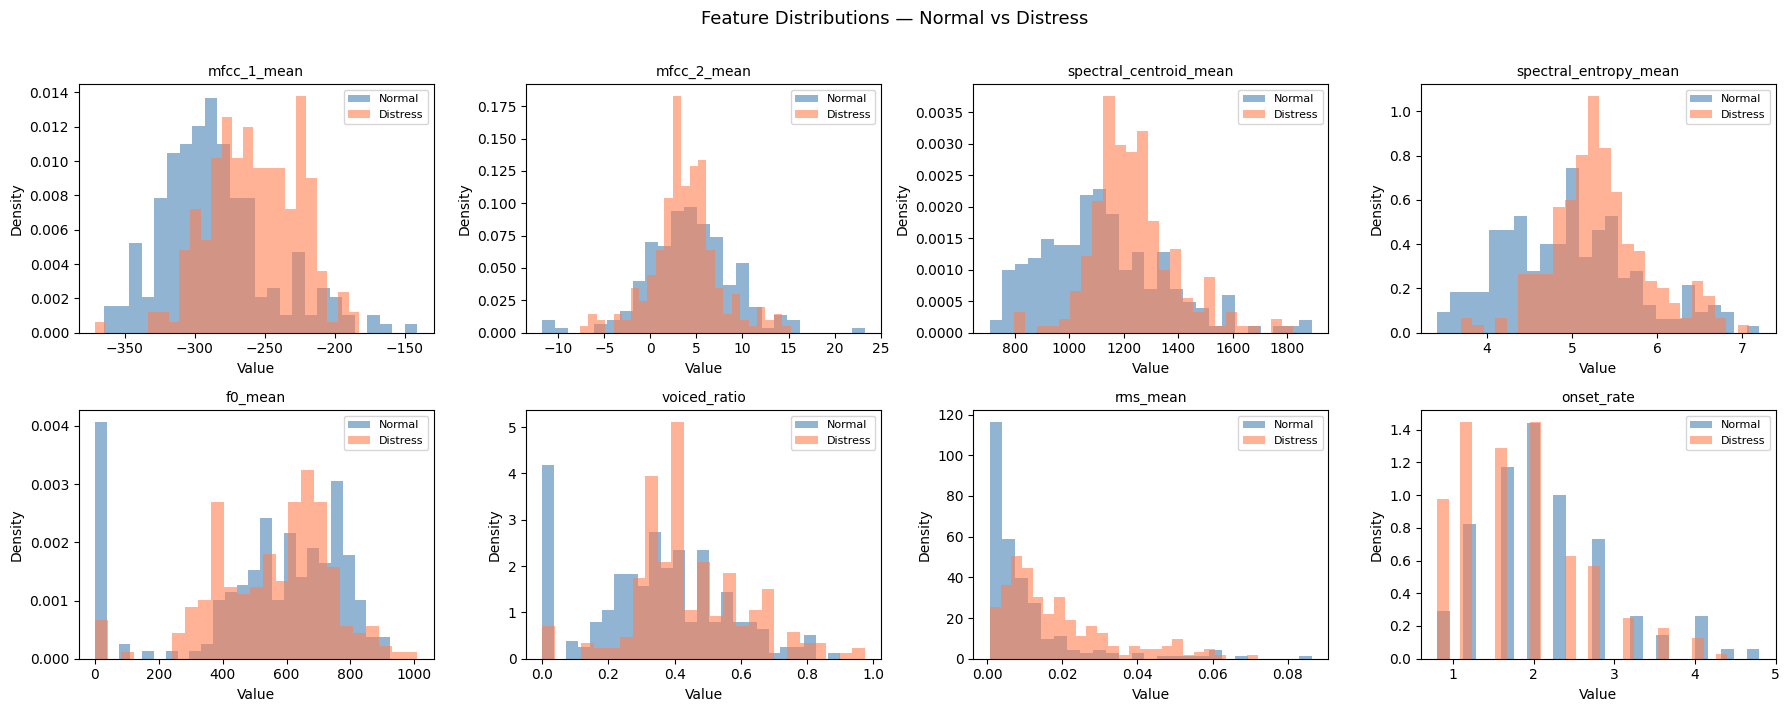

In [16]:
# Distribution of key features by class
key_features = [
    'mfcc_1_mean', 'mfcc_2_mean',
    'spectral_centroid_mean', 'spectral_entropy_mean',
    'f0_mean', 'voiced_ratio',
    'rms_mean', 'onset_rate'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for label, colour, name in [(0, 'steelblue', 'Normal'), (1, 'coral', 'Distress')]:
        data = features_df[features_df['binary_label'] == label][feat].dropna()
        axes[i].hist(data, bins=25, alpha=0.6, color=colour, label=name, density=True)
    axes[i].set_title(feat, fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')

plt.suptitle('Feature Distributions — Normal vs Distress', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

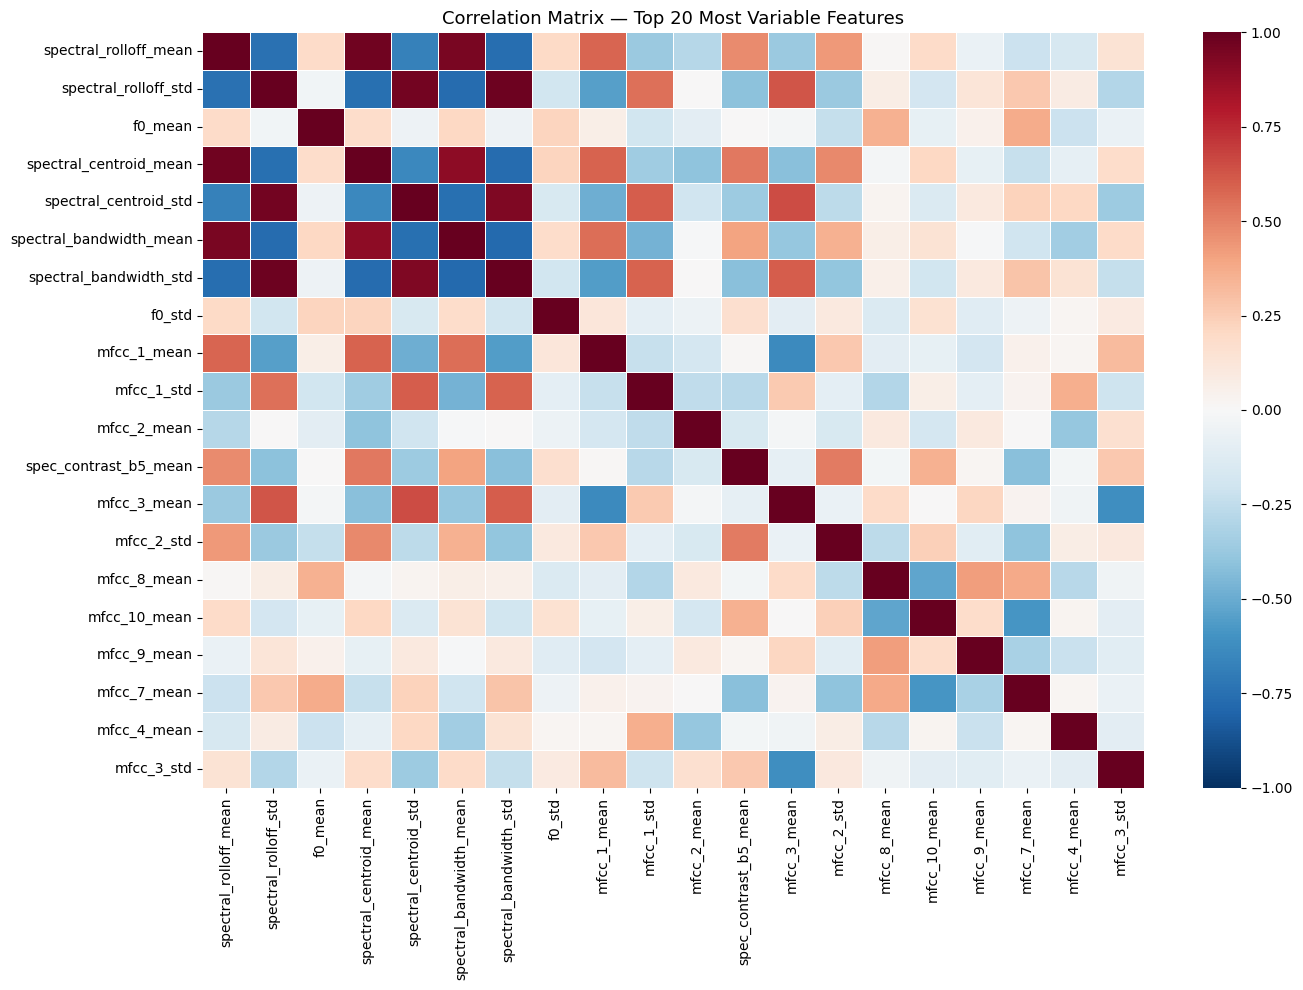

In [17]:
# Correlation heatmap of top-20 most-variable features
variances = features_df[feature_cols].var().sort_values(ascending=False)
top20 = variances.head(20).index.tolist()

fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = features_df[top20].corr()
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.4, ax=ax, annot=False)
ax.set_title('Correlation Matrix — Top 20 Most Variable Features', fontsize=13)
plt.tight_layout()
plt.show()

In [18]:
# Check for missing/infinite values in feature matrix
X_check = features_df[feature_cols]
print("NaN count per feature (top 10):")
print(X_check.isnull().sum().sort_values(ascending=False).head(10))
print("\nInf count per feature (top 10):")
print(np.isinf(X_check.values).sum(axis=0).max())

NaN count per feature (top 10):
mfcc_1_mean    0
mfcc_1_std     0
mfcc_2_mean    0
mfcc_2_std     0
mfcc_3_mean    0
mfcc_3_std     0
mfcc_4_mean    0
mfcc_4_std     0
mfcc_5_mean    0
mfcc_5_std     0
dtype: int64

Inf count per feature (top 10):
0


---
## 6 · Modelling

### Cross-validation Strategy: StratifiedGroupKFold

**Why GroupKFold?** We have multiple recordings from the same cat. If we split randomly, the model could learn individual cat voices rather than distress patterns — then generalise poorly to new cats. Using `cat_id` as the group ensures **no cat appears in both train and validation** within any fold.

**Why Stratified?** Our classes are slightly imbalanced, so we maintain class proportions in each fold.

In [32]:
# Prepare X, y, groups
X      = features_df[feature_cols].copy()
y      = features_df['binary_label'].values
groups = features_df['cat_id'].values

# Replace any NaN/Inf (e.g. pyin returning NaN on silence frames)
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())

print(f"X: {X.shape} | Class balance: {np.bincount(y)} | Cats: {np.unique(groups).shape[0]}")

X: (434, 81) | Class balance: [213 221] | Cats: 21


In [43]:
# Cross-validation loop
# We compare three models:
#   1. DummyClassifier (majority-class baseline)
#   2. RandomForest    (strong non-linear baseline)
#   3. LightGBM        (our primary model)

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    'Dummy':        DummyClassifier(strategy='most_frequent', random_state=SEED),
    'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=8, random_state=SEED, n_jobs=-1),
    'LightGBM': lgb.LGBMClassifier(
      n_estimators=500,
      learning_rate=0.05,
      num_leaves=31,
      min_child_samples=5,
      subsample=0.8,
      colsample_bytree=0.8,
      scale_pos_weight=213/221,  # n_normal / n_distress from your class balance output
      random_state=SEED,
      verbose=-1
)
}

cv_results = {name: {'auc': [], 'recall_distress': [], 'precision_distress': []} for name in models}

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y, groups)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Scale features (important for RandomForest less so, but good practice)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s   = scaler.transform(X_val)

    for name, model in models.items():
        model.fit(X_train_s, y_train)
        proba = model.predict_proba(X_val_s)[:, 1]

        # Apply decision threshold
        preds = (proba >= DECISION_THRESHOLD).astype(int)

        auc = roc_auc_score(y_val, proba)
        report = classification_report(y_val, preds, output_dict=True, zero_division=0)

        cv_results[name]['auc'].append(auc)
        cv_results[name]['recall_distress'].append(report.get('1', {}).get('recall', 0))
        cv_results[name]['precision_distress'].append(report.get('1', {}).get('precision', 0))

    print(f"Fold {fold+1} — val cats: {np.unique(groups[val_idx])}")

print("\nCross-validation complete ✓")

Fold 1 — val cats: ['BRA01' 'MAG01']
Fold 2 — val cats: ['BAC01' 'BLE01' 'MAT01' 'MEG01' 'NUL01']
Fold 3 — val cats: ['BRI01' 'DAK01' 'JJX01' 'NIG01' 'TIG01']
Fold 4 — val cats: ['ANI01' 'CAN01' 'CLE01' 'LEO01']
Fold 5 — val cats: ['IND01' 'MIN01' 'REG01' 'SPI01' 'WHO01']

Cross-validation complete ✓


In [44]:
# Summary table
summary_rows = []
for name, res in cv_results.items():
    summary_rows.append({
        'Model': name,
        'AUC (mean ± std)':         f"{np.mean(res['auc']):.3f} ± {np.std(res['auc']):.3f}",
        'Recall-Distress (mean)':   f"{np.mean(res['recall_distress']):.3f}",
        'Precision-Distress (mean)':f"{np.mean(res['precision_distress']):.3f}",
    })

summary_df = pd.DataFrame(summary_rows)
print("=== Cross-Validation Results ===")
print(summary_df.to_string(index=False))

=== Cross-Validation Results ===
       Model AUC (mean ± std) Recall-Distress (mean) Precision-Distress (mean)
       Dummy    0.500 ± 0.000                  0.600                     0.234
RandomForest    0.823 ± 0.058                  0.873                     0.626
    LightGBM    0.809 ± 0.067                  0.670                     0.753


---
## 7 · Threshold Optimisation

The default threshold of 0.5 is rarely optimal for imbalanced datasets where recall matters most. For distress detection, **a missed distress (false negative) is worse than a false alarm (false positive)** — so we prioritise recall.

We use the **precision-recall curve** to pick the threshold that maximises F2 score (which weights recall twice as heavily as precision).

In [35]:
cat_label_counts = (
    features_df.groupby('cat_id')['binary_label']
    .value_counts()
    .unstack(fill_value=0)
    .rename(columns={0: 'n_normal', 1: 'n_distress'})
)
cat_label_counts['total'] = cat_label_counts.sum(axis=1)
print("Recordings per cat:")
print(cat_label_counts.sort_values('total', ascending=False).to_string())

Recordings per cat:
binary_label  n_normal  n_distress  total
cat_id                                   
CAN01               28          26     54
BLE01                3          45     48
DAK01                8          32     40
WHO01               20          18     38
MAG01               24           3     27
SPI01               12          15     27
BAC01               17           7     24
MAT01               13          10     23
IND01               21           0     21
CLE01                0          20     20
BRA01                8          10     18
BRI01               15           0     15
NUL01                4          10     14
MEG01                4          10     14
MIN01                8           6     14
ANI01                6           4     10
JJX01                7           0      7
LEO01                5           0      5
NIG01                4           1      5
REG01                4           1      5
TIG01                2           3      5


In [36]:
# Fit final LightGBM on full data & examine threshold
# We do a single 80/20 hold-out by cat (last 20% of cats)

# ── Hold-out split: stratify by BOTH cat and class ────────────────────────────
# Instead of taking the last 4 cats alphabetically, we deliberately pick
# hold-out cats so that both classes are reasonably represented.
# Target: ~20% of recordings, with at least 5 distress and 5 normal recordings.

holdout_cats = ['SPI01', 'WHO01']   # ← well-balanced cats
train_cats   = [c for c in np.unique(groups) if c not in holdout_cats]

train_mask = np.isin(groups, train_cats)
val_mask   = np.isin(groups, holdout_cats)

X_train, X_val = X[train_mask], X[val_mask]
y_train, y_val = y[train_mask],  y[val_mask]

scaler_final = StandardScaler()
X_train_s = scaler_final.fit_transform(X_train)
X_val_s   = scaler_final.transform(X_val)

lgbm_final = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=31,
    min_child_samples=5, subsample=0.8, colsample_bytree=0.8,
    class_weight='balanced', random_state=SEED, verbose=-1
)
lgbm_final.fit(X_train_s, y_train)
val_proba = lgbm_final.predict_proba(X_val_s)[:, 1]

print(f"Train: {train_mask.sum()} recordings ({np.isin(groups[train_mask], train_cats).sum()} cats)")
print(f"Val  : {val_mask.sum()} recordings")
print(f"Val class balance: {np.bincount(y[val_mask])}")  # should be roughly even

Train: 369 recordings (369 cats)
Val  : 65 recordings
Val class balance: [32 33]


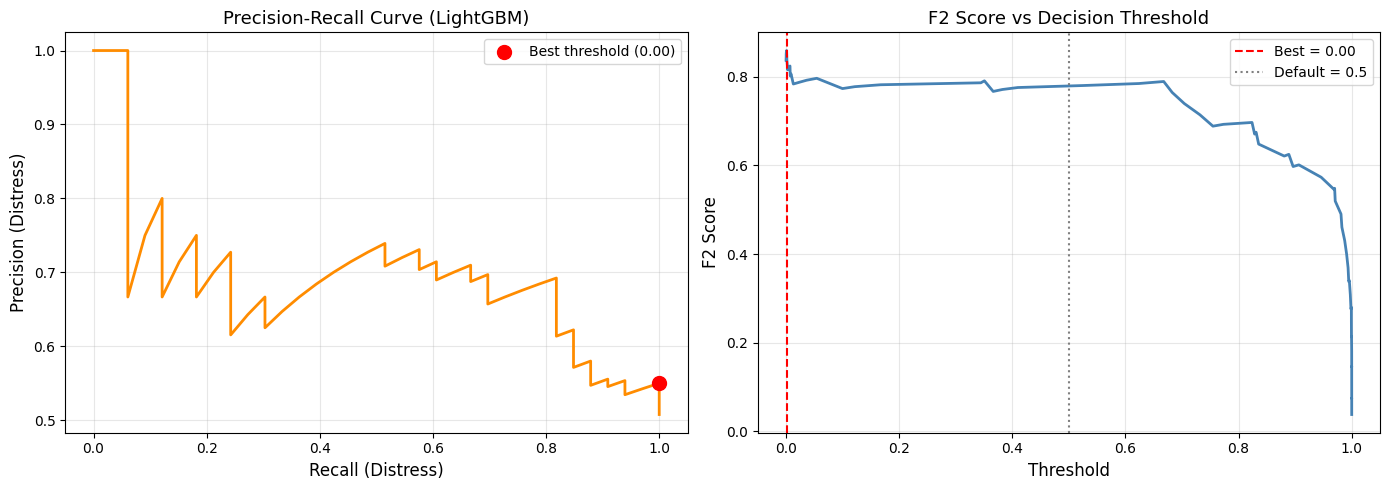


Optimal threshold (F2): 0.001


In [37]:
# Precision-Recall curve + F-beta optimisation
precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba)

# F2 score: beta=2 means recall is valued 2× more than precision
beta = 2
f_beta = ((1 + beta**2) * precisions * recalls) / (beta**2 * precisions + recalls + 1e-9)
best_idx = np.argmax(f_beta[:-1])   # last element has no matching threshold
best_threshold = thresholds[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall curve
axes[0].plot(recalls, precisions, color='darkorange', lw=2)
axes[0].scatter(recalls[best_idx], precisions[best_idx],
                color='red', zorder=5, s=100, label=f'Best threshold ({best_threshold:.2f})')
axes[0].set_xlabel('Recall (Distress)', fontsize=12)
axes[0].set_ylabel('Precision (Distress)', fontsize=12)
axes[0].set_title('Precision-Recall Curve (LightGBM)', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F2 score vs threshold
axes[1].plot(thresholds, f_beta[:-1], color='steelblue', lw=2)
axes[1].axvline(best_threshold, color='red', linestyle='--', lw=1.5, label=f'Best = {best_threshold:.2f}')
axes[1].axvline(0.5, color='gray', linestyle=':', lw=1.5, label='Default = 0.5')
axes[1].set_xlabel('Threshold', fontsize=12)
axes[1].set_ylabel('F2 Score', fontsize=12)
axes[1].set_title('F2 Score vs Decision Threshold', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"\nOptimal threshold (F2): {best_threshold:.3f}")

---
## 8 · Evaluation & Interpretation

In [38]:
# Final evaluation at optimised threshold
final_threshold = best_threshold   # or manually set DECISION_THRESHOLD from config
val_preds = (val_proba >= final_threshold).astype(int)

print(f"{'='*50}")
print(f"  Evaluation at threshold = {final_threshold:.3f}")
print(f"{'='*50}")
print(classification_report(y_val, val_preds,
                             target_names=['Normal (0)', 'Distress (1)'],
                             digits=3))

  Evaluation at threshold = 0.001
              precision    recall  f1-score   support

  Normal (0)      1.000     0.156     0.270        32
Distress (1)      0.550     1.000     0.710        33

    accuracy                          0.585        65
   macro avg      0.775     0.578     0.490        65
weighted avg      0.772     0.585     0.493        65



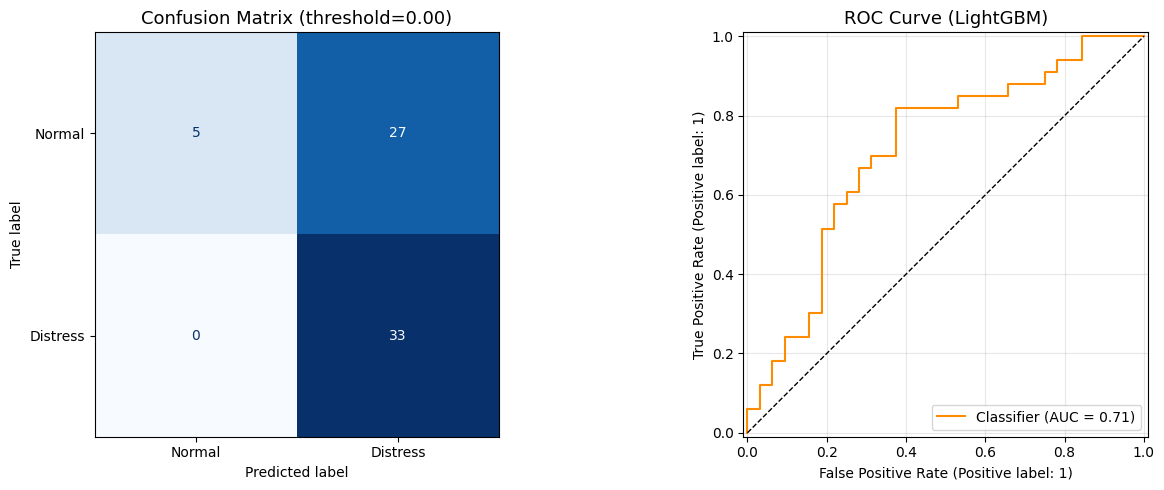

In [39]:
# onfusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_val, val_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Distress'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix (threshold={final_threshold:.2f})', fontsize=13)

# ROC curve
RocCurveDisplay.from_predictions(y_val, val_proba, ax=axes[1], color='darkorange')
axes[1].set_title('ROC Curve (LightGBM)', fontsize=13)
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

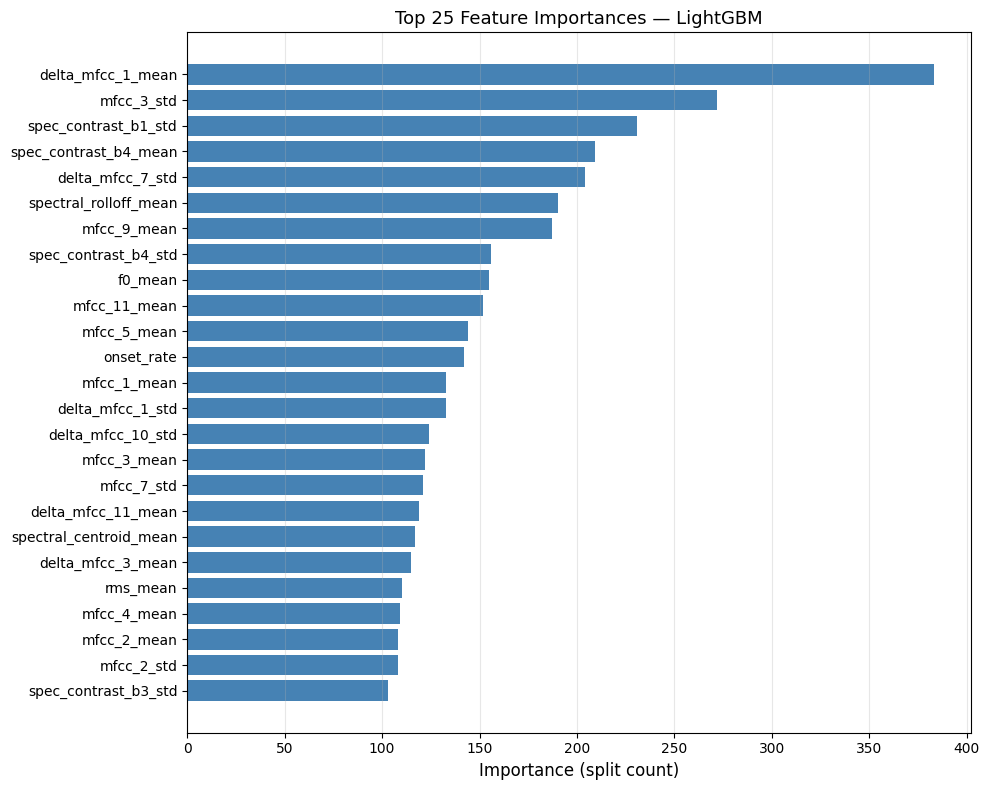


Top 10 most important features:
              feature  importance
    delta_mfcc_1_mean         383
           mfcc_3_std         272
 spec_contrast_b1_std         231
spec_contrast_b4_mean         209
     delta_mfcc_7_std         204
spectral_rolloff_mean         190
          mfcc_9_mean         187
 spec_contrast_b4_std         156
              f0_mean         155
         mfcc_11_mean         152


In [40]:
# Feature importance
importance_df = pd.DataFrame({
    'feature':   feature_cols,
    'importance': lgbm_final.feature_importances_
}).sort_values('importance', ascending=False)

top_n = 25
fig, ax = plt.subplots(figsize=(10, 8))
top_feats = importance_df.head(top_n)
ax.barh(top_feats['feature'][::-1], top_feats['importance'][::-1], color='steelblue')
ax.set_xlabel('Importance (split count)', fontsize=12)
ax.set_title(f'Top {top_n} Feature Importances — LightGBM', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(importance_df.head(10).to_string(index=False))

In [41]:
# Per-cat performance breakdown
# Check if the model struggles more with certain cats (potential data leakage check)

val_df = features_df[val_mask].copy()
val_df['predicted_proba'] = val_proba
val_df['predicted_label'] = val_preds
val_df['correct'] = (val_df['predicted_label'] == val_df['binary_label']).astype(int)

cat_summary = val_df.groupby(['cat_id', 'binary_label']).agg(
    n_recordings=('correct', 'count'),
    accuracy=('correct', 'mean'),
    mean_proba=('predicted_proba', 'mean')
).round(3)

print("Per-cat / per-class performance on hold-out set:")
print(cat_summary.to_string())

Per-cat / per-class performance on hold-out set:
                     n_recordings  accuracy  mean_proba
cat_id binary_label                                    
SPI01  0                       12     0.167       0.336
       1                       15     1.000       0.689
WHO01  0                       20     0.150       0.510
       1                       18     1.000       0.832


### Tuning of LightGBM

In [46]:
! pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 11.0 MB/s eta 0:00:00


In [48]:
# pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 800),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 8, 64),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 40),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'class_weight'     : 'balanced',
        'random_state'     : SEED,
        'verbose'          : -1,
    }

    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    aucs = []

    for train_idx, val_idx in cv.split(X, y, groups):
        scaler_f = StandardScaler() # Initialize StandardScaler for each fold
        X_tr  = scaler_f.fit_transform(X.iloc[train_idx])
        X_val = scaler_f.transform(X.iloc[val_idx])
        y_tr, y_val = y[train_idx], y[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_val)[:, 1]
        aucs.append(roc_auc_score(y_val, proba))

    return np.mean(aucs)   # Optuna maximises this

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"Best CV AUC : {study.best_value:.3f}")
print(f"Best params : {study.best_params}")

  0%|          | 0/100 [00:00<?, ?it/s]

Best CV AUC : 0.822
Best params : {'n_estimators': 454, 'learning_rate': 0.04268564394023811, 'num_leaves': 10, 'min_child_samples': 11, 'subsample': 0.8819770497632673, 'colsample_bytree': 0.5148245971892409, 'reg_alpha': 0.00017726178813452846, 'reg_lambda': 0.007438304815706198}


In [49]:
# Compare model performance with and without food recordings
# to see if they're adding noise to the normal class

df_no_food = features_df[features_df['context'] != 'food'].copy()

X_nf      = df_no_food[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(X.median())
y_nf      = df_no_food['binary_label'].values
groups_nf = df_no_food['cat_id'].values

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
aucs_nf = []

for train_idx, val_idx in cv.split(X_nf, y_nf, groups_nf):
    scaler_nf = StandardScaler()
    X_tr  = scaler_nf.fit_transform(X_nf.iloc[train_idx])
    X_val = scaler_nf.transform(X_nf.iloc[val_idx])

    model = lgb.LGBMClassifier(
        **study.best_params,   # use tuned params
        class_weight='balanced', random_state=SEED, verbose=-1
    )
    model.fit(X_tr, y_nf[train_idx])
    proba = model.predict_proba(X_val)[:, 1]
    aucs_nf.append(roc_auc_score(y_nf[val_idx], proba))

print(f"CV AUC with food   : {np.mean(aucs_nf):.3f}")   # compare to your current 0.80-0.82
print(f"CV AUC without food (all contexts): see above")
# If removing food improves AUC meaningfully, exclude it from training

CV AUC with food   : 0.818
CV AUC without food (all contexts): see above


In [50]:
# ── Re-run hold-out evaluation with tuned model ───────────────────────────────
# Using SPI01 and WHO01 as hold-out cats (well-balanced, discussed earlier)

holdout_cats = ['SPI01', 'WHO01']
train_cats   = [c for c in np.unique(groups) if c not in holdout_cats]

train_mask = np.isin(groups, train_cats)
val_mask   = np.isin(groups, holdout_cats)

scaler_final = StandardScaler()
X_tr_f  = scaler_final.fit_transform(X[train_mask])
X_val_f = scaler_final.transform(X[val_mask])
y_tr_f  = y[train_mask]
y_val_f = y[val_mask]

print(f"Train: {train_mask.sum()} recordings, {len(train_cats)} cats")
print(f"Val  : {val_mask.sum()} recordings — cats: {holdout_cats}")
print(f"Val class balance: normal={np.sum(y_val_f==0)}, distress={np.sum(y_val_f==1)}")

Train: 369 recordings, 19 cats
Val  : 65 recordings — cats: ['SPI01', 'WHO01']
Val class balance: normal=32, distress=33


In [51]:
# Fit tuned LightGBM (best_params from Optuna)
lgbm_tuned = lgb.LGBMClassifier(
    **study.best_params,
    class_weight='balanced',
    random_state=SEED,
    verbose=-1
)
lgbm_tuned.fit(X_tr_f, y_tr_f)
val_proba = lgbm_tuned.predict_proba(X_val_f)[:, 1]

print(f"Hold-out AUC (tuned LightGBM): {roc_auc_score(y_val_f, val_proba):.3f}")
print(f"Hold-out AUC (compare — untuned was 0.647)")

Hold-out AUC (tuned LightGBM): 0.723
Hold-out AUC (compare — untuned was 0.647)


In [52]:
# ── Threshold optimisation on hold-out probabilities ─────────────────────────
# We optimise F2 (beta=2) which weights recall twice as heavily as precision.
# Constraint: only consider thresholds >= 0.05 to avoid degenerate t=0 solution
# seen in the earlier run.

precisions, recalls, thresholds = precision_recall_curve(y_val_f, val_proba)

beta = 2
f2   = ((1 + beta**2) * precisions * recalls) / (beta**2 * precisions + recalls + 1e-9)

# Restrict search range
valid_mask     = thresholds >= 0.05
best_i         = np.argmax(f2[:-1][valid_mask])
best_threshold = float(thresholds[valid_mask][best_i])

print(f"Optimal threshold : {best_threshold:.3f}")
print(f"F2 at threshold   : {f2[:-1][valid_mask][best_i]:.3f}")

Optimal threshold : 0.135
F2 at threshold   : 0.820


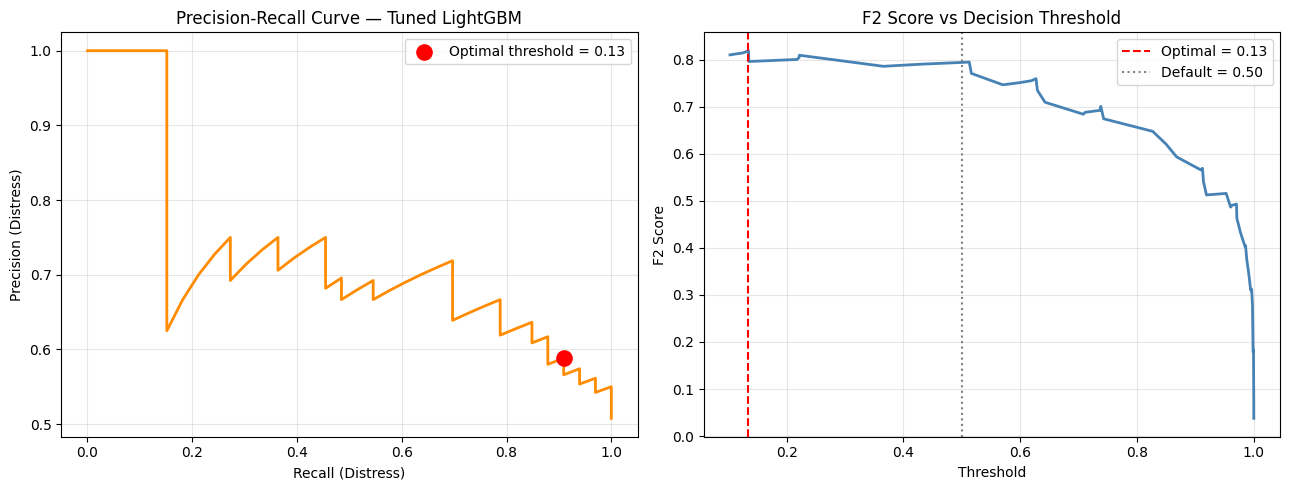

In [53]:
# ── Visualise precision-recall curve and F2 vs threshold ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Precision-recall curve
axes[0].plot(recalls, precisions, color='darkorange', lw=2)
axes[0].scatter(
    recalls[:-1][valid_mask][best_i],
    precisions[:-1][valid_mask][best_i],
    color='red', s=120, zorder=5,
    label=f'Optimal threshold = {best_threshold:.2f}'
)
axes[0].set_xlabel('Recall (Distress)')
axes[0].set_ylabel('Precision (Distress)')
axes[0].set_title('Precision-Recall Curve — Tuned LightGBM')
axes[0].legend()
axes[0].grid(alpha=0.3)

# F2 vs threshold
axes[1].plot(thresholds[valid_mask], f2[:-1][valid_mask], color='steelblue', lw=2)
axes[1].axvline(best_threshold, color='red',  linestyle='--', lw=1.5,
                label=f'Optimal = {best_threshold:.2f}')
axes[1].axvline(0.5,            color='gray', linestyle=':',  lw=1.5,
                label='Default = 0.50')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F2 Score')
axes[1].set_title('F2 Score vs Decision Threshold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
# ── Final evaluation at optimal threshold ─────────────────────────────────────
final_preds = (val_proba >= best_threshold).astype(int)

print(f"{'='*54}")
print(f"  Final Evaluation — Tuned LightGBM")
print(f"  Threshold = {best_threshold:.3f}  |  Hold-out AUC = {roc_auc_score(y_val_f, val_proba):.3f}")
print(f"{'='*54}")
print(classification_report(
    y_val_f, final_preds,
    target_names=['Normal', 'Distress'],
    digits=3
))

  Final Evaluation — Tuned LightGBM
  Threshold = 0.135  |  Hold-out AUC = 0.723
              precision    recall  f1-score   support

      Normal      0.786     0.344     0.478        32
    Distress      0.588     0.909     0.714        33

    accuracy                          0.631        65
   macro avg      0.687     0.626     0.596        65
weighted avg      0.685     0.631     0.598        65



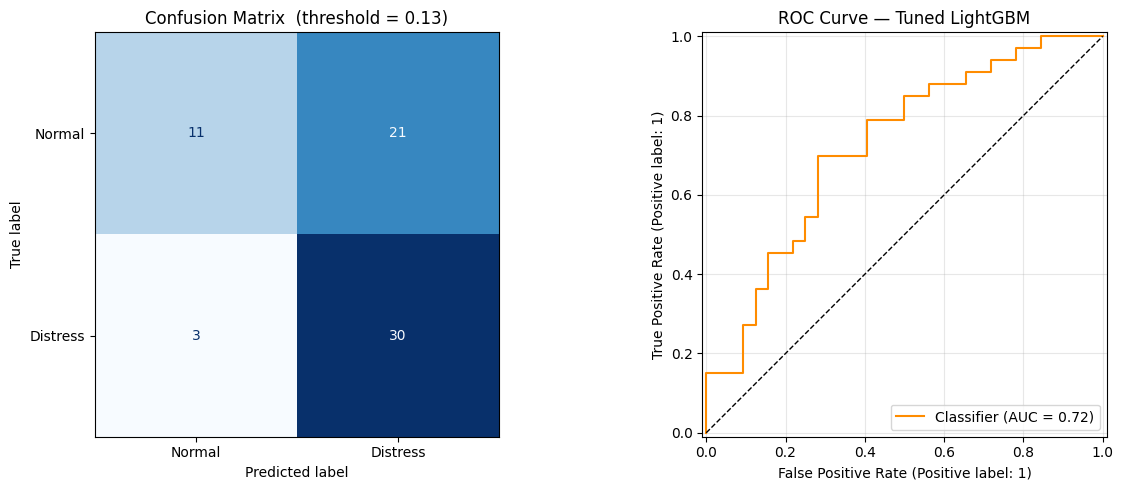

In [55]:
# ── Confusion matrix + ROC side by side ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_val_f, final_preds),
    display_labels=['Normal', 'Distress']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix  (threshold = {best_threshold:.2f})')

RocCurveDisplay.from_predictions(
    y_val_f, val_proba, ax=axes[1], color='darkorange'
)
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title('ROC Curve — Tuned LightGBM')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [56]:
# ── Per-cat breakdown on hold-out ─────────────────────────────────────────────
val_df = features_df[val_mask].copy()
val_df['predicted_proba'] = val_proba
val_df['predicted_label'] = final_preds
val_df['correct']         = (val_df['predicted_label'] == val_df['binary_label']).astype(int)

cat_summary = val_df.groupby(['cat_id', 'binary_label']).agg(
    n_recordings = ('correct', 'count'),
    accuracy     = ('correct', 'mean'),
    mean_proba   = ('predicted_proba', 'mean')
).round(3)

print("Per-cat performance on hold-out:")
print(cat_summary.to_string())

Per-cat performance on hold-out:
                     n_recordings  accuracy  mean_proba
cat_id binary_label                                    
SPI01  0                       12     0.417       0.410
       1                       15     0.867       0.728
WHO01  0                       20     0.300       0.510
       1                       18     0.944       0.784


In [57]:
# Run leave-one-cat-out evaluation to get a more stable picture
# than a single 2-cat hold-out

from sklearn.metrics import roc_auc_score

loco_results = []   # leave-one-cat-out

for held_cat in np.unique(groups):
    mask_train = groups != held_cat
    mask_val   = groups == held_cat

    # Skip cats with only one class — AUC undefined
    if len(np.unique(y[mask_val])) < 2:
        print(f"Skipping {held_cat} — only one class in hold-out")
        continue

    sc = StandardScaler()
    X_tr  = sc.fit_transform(X[mask_train])
    X_val = sc.transform(X[mask_val])

    m = lgb.LGBMClassifier(
        **study.best_params,
        class_weight='balanced',
        random_state=SEED,
        verbose=-1
    )
    m.fit(X_tr, y[mask_train])
    proba = m.predict_proba(X_val)[:, 1]
    auc   = roc_auc_score(y[mask_val], proba)

    loco_results.append({
        'cat_id'     : held_cat,
        'n_val'      : mask_val.sum(),
        'auc'        : round(auc, 3),
        'n_normal'   : int(np.sum(y[mask_val] == 0)),
        'n_distress' : int(np.sum(y[mask_val] == 1)),
    })

loco_df = pd.DataFrame(loco_results).sort_values('auc')
print(loco_df.to_string(index=False))
print(f"\nMean LOCO AUC : {loco_df['auc'].mean():.3f}")
print(f"Std  LOCO AUC : {loco_df['auc'].std():.3f}")
print(f"Min  LOCO AUC : {loco_df['auc'].min():.3f}  ← worst individual cat")
print(f"Max  LOCO AUC : {loco_df['auc'].max():.3f}  ← best individual cat")

Skipping BRI01 — only one class in hold-out
Skipping CLE01 — only one class in hold-out
Skipping IND01 — only one class in hold-out
Skipping JJX01 — only one class in hold-out
Skipping LEO01 — only one class in hold-out
cat_id  n_val   auc  n_normal  n_distress
 NIG01      5 0.000         4           1
 REG01      5 0.500         4           1
 WHO01     38 0.658        20          18
 SPI01     27 0.683        12          15
 CAN01     54 0.699        28          26
 MIN01     14 0.833         8           6
 TIG01      5 0.833         2           3
 MEG01     14 0.850         4          10
 BLE01     48 0.852         3          45
 MAG01     27 0.875        24           3
 BAC01     24 0.882        17           7
 BRA01     18 0.938         8          10
 NUL01     14 0.950         4          10
 ANI01     10 0.958         6           4
 DAK01     40 0.973         8          32
 MAT01     23 1.000        13          10

Mean LOCO AUC : 0.780
Std  LOCO AUC : 0.248
Min  LOCO AUC : 0.000

In [58]:
# Recompute mean excluding NIG01 (n_distress=1, statistically uninformative)
loco_filtered = loco_df[loco_df['cat_id'] != 'NIG01']

print(f"LOCO AUC (all 16 evaluable cats)          : {loco_df['auc'].mean():.3f} ± {loco_df['auc'].std():.3f}")
print(f"LOCO AUC (excluding NIG01, n_distress=1)  : {loco_filtered['auc'].mean():.3f} ± {loco_filtered['auc'].std():.3f}")
print(f"Cats with AUC >= 0.80 : {(loco_df['auc'] >= 0.80).sum()} / {len(loco_df)}")
print(f"Cats with AUC >= 0.70 : {(loco_df['auc'] >= 0.70).sum()} / {len(loco_df)}")

LOCO AUC (all 16 evaluable cats)          : 0.780 ± 0.248
LOCO AUC (excluding NIG01, n_distress=1)  : 0.832 ± 0.140
Cats with AUC >= 0.80 : 11 / 16
Cats with AUC >= 0.70 : 11 / 16


In [62]:
import joblib

artefacts = {
    'model'          : lgbm_final,
    'scaler'         : scaler_final, # Changed from scaler_f to scaler_final
    'feature_cols'   : feature_cols,
    'threshold'      : best_threshold,
    'native_sr'      : NATIVE_SR,
    'target_duration': TARGET_DURATION,
    'n_mfcc'         : N_MFCC,
    'n_mels'         : N_MELS,
    'n_fft'          : N_FFT,
    'hop_length'     : HOP_LENGTH,
}

joblib.dump(artefacts, 'cat_distress_model.joblib')
print("Saved ✓")

Saved ✓
